# 0. Course overview and setup

Welcome. This is a complete, self-contained course in **machine learning with Python** —
twenty-one notebooks that take you from "I can write a `for` loop" to "I can frame a
business problem as a learning problem, choose and tune an appropriate model, evaluate it
honestly, explain what it does, and put it into production responsibly."

The course is **hands-on**: every idea is explained in prose and mathematics, then
implemented, then tested on data. Most algorithms are written twice — once from scratch in
NumPy, so that nothing is magic, and once with scikit-learn, so that you learn the tools
you will actually use. Every method notebook ends with the same three sections: what the
method is good and bad at, how to tune it, and a worked case study on real data.

**What this course is not.** It does not cover deep learning. Neural networks, PyTorch,
convolutional networks and transformers are a large subject with their own prerequisites
and their own course; where they are the natural continuation of a topic, this course says
so in a sentence and moves on. What you will find here is *classical statistical machine
learning*, covered in depth — which is still, on the tabular data that most organisations
actually have, the set of methods that wins.

This notebook is the front door: the map, the setup instructions, a ten-minute taste of the
whole workflow, and the conventions used throughout.

## Learning objectives

After working through this notebook you will be able to

- describe what the course covers, in what order, and which path through it suits you;
- create the `ml-course` conda environment and verify that every required package works;
- find your way around the repository: notebooks, data, helper module, bibliography;
- run a complete supervised-learning workflow — split, pipeline, baseline, model, cross-validation, evaluation, interpretation — and name the notebook that explains each step;
- use the course conventions: notation, the helper functions in `course_utils`, the colour palette, exercises and solution sketches, citations;
- tell which of the bundled datasets are real and which are simulated, and why the course uses both.

## 1. How to use this course

Each notebook is a self-contained lesson of roughly two to four hours, structured the same
way: motivation, learning objectives, numbered sections that move from intuition through
mathematics to code and experiments, then a summary with a cheat-sheet table, exercises
with solution sketches, and a reference list for going deeper.

Work through them **by running them**. Reading a notebook takes twenty minutes; running it,
changing a parameter, and watching what happens to the figure takes two hours and teaches
you ten times as much. The exercises at the end of every notebook are where the learning
consolidates — do at least the first two or three of each set before moving on. Solution
sketches are provided in collapsible blocks; resist them for twenty minutes first.

The whole course is about **50–70 hours** of work if you do the exercises. There is no
deadline. A sustainable pace is one notebook a week.

> **Key idea.** Machine learning is an empirical discipline. Nothing in it is settled by
> argument; everything is settled by an experiment on held-out data. This course is
> organised around that habit, and the single most important notebook is number 5, which
> teaches you how to run those experiments without fooling yourself.

## Setup

Everything you need is in one conda environment. From the course folder:

```bash
conda env create -f environment.yml     # or: mamba env create -f environment.yml
conda activate ml-course
jupyter lab
```

Then open `notebooks/01_python_numpy_pandas_for_ml.ipynb` and start. If you do not have
conda, [Miniforge](https://github.com/conda-forge/miniforge) is a small, free installer
that works on Linux, macOS and Windows. (A `pip install -r` route also works — the
environment file lists exactly the same packages — but conda handles the compiled
scientific stack more reliably across platforms.)

The environment splits into a **core** block (NumPy, pandas, SciPy, scikit-learn,
matplotlib, seaborn, JupyterLab) that every notebook needs, and an **optional** block
(statsmodels, XGBoost, LightGBM, SHAP, Optuna, UMAP, NLTK, gensim, fairlearn, Flask) used
only by clearly marked sections. Every optional import is wrapped in `try/except`, so a
notebook always runs to the end; where a package is missing it prints one line and skips
that section. If the optional block is slow to solve on your platform, delete those lines
from `environment.yml` — you will lose a handful of comparisons, nothing structural.

No GPU is required. Every notebook runs on a laptop CPU in a few minutes.

The cell below verifies your installation. Run it now: it prints the version of everything
the course uses and tells you plainly whether anything essential is missing.

In [1]:
import importlib
import platform
import sys

CORE = ["numpy", "pandas", "scipy", "sklearn", "matplotlib", "seaborn"]
OPTIONAL = {
    "statsmodels": "notebook 16 (ARIMA, STL decomposition)",
    "xgboost": "notebook 10 (boosting comparison)",
    "lightgbm": "notebook 10 (boosting comparison)",
    "shap": "notebook 17 (SHAP plots)",
    "optuna": "notebook 12 (Bayesian hyper-parameter search)",
    "umap": "notebook 14 (UMAP embeddings)",
    "nltk": "notebook 15 (tokenisers, stop words)",
    "gensim": "notebook 15 (word2vec)",
    "fairlearn": "notebook 19 (fairness metrics)",
    "flask": "notebook 18 (prediction endpoint)",
}

def version_of(name):
    """Return the installed version of a package, or None if it is not installed."""
    try:
        importlib.import_module(name)
    except ImportError:
        return None
    try:                                   # the modern, warning-free way
        from importlib.metadata import version, PackageNotFoundError
        return version({"sklearn": "scikit-learn", "umap": "umap-learn"}.get(name, name))
    except Exception:
        return "installed"

print(f"Python {platform.python_version()} on {platform.system()}  ({sys.executable})\n")
print("core packages (required)")
missing_core = []
for name in CORE:
    v = version_of(name)
    print(f"  {name:14s} {v if v else 'MISSING'}")
    if v is None:
        missing_core.append(name)

print("\noptional packages (guarded sections only)")
for name, where in OPTIONAL.items():
    v = version_of(name)
    mark = v if v else "not installed — that section will be skipped"
    print(f"  {name:14s} {mark:22s} {where}")

print()
if missing_core:
    print(f"!! {', '.join(missing_core)} missing. Run:  conda env create -f environment.yml")
else:
    print("All core packages are present — you are ready to start with notebook 1.")

Python 3.11.15 on Linux  (/usr/bin/python3)

core packages (required)
  numpy          2.4.4
  pandas         3.0.2
  scipy          1.17.1
  sklearn        1.8.0
  matplotlib     3.10.9
  seaborn        0.13.2

optional packages (guarded sections only)
  statsmodels    not installed — that section will be skipped notebook 16 (ARIMA, STL decomposition)
  xgboost        not installed — that section will be skipped notebook 10 (boosting comparison)
  lightgbm       not installed — that section will be skipped notebook 10 (boosting comparison)
  shap           not installed — that section will be skipped notebook 17 (SHAP plots)
  optuna         not installed — that section will be skipped notebook 12 (Bayesian hyper-parameter search)
  umap           not installed — that section will be skipped notebook 14 (UMAP embeddings)
  nltk           not installed — that section will be skipped notebook 15 (tokenisers, stop words)
  gensim         not installed — that section will be skipped noteb

A second check: the course helper module and the bundled data.

In [2]:
import sys
from pathlib import Path

# Notebooks are run from the notebooks/ folder, where course_utils.py lives.
import course_utils as cu

cu.set_style()
churn = cu.load_churn()
print(f"course_utils loaded from {Path(cu.__file__).resolve().parent}")
print(f"bundled churn data: {churn.shape[0]} rows x {churn.shape[1]} columns")
print(f"data folder: {cu.DATA_DIR.resolve()}")
print("available loaders:", ", ".join(n for n in cu.__all__ if n.startswith("load_")))

course_utils loaded from /home/claude/ml-course-build/course/notebooks
bundled churn data: 5000 rows x 15 columns
data folder: /home/claude/ml-course-build/course/data
available loaders: load_churn, load_energy_demand, load_loans, load_reviews, load_air_passengers, load_california_housing, load_penguins, load_adult, load_newsgroups


## 2. The map

Twenty-one notebooks in five blocks. Read the table, then look at the dependency figure
below it — you do not have to go strictly in order.

| # | Notebook | What you get out of it |
|---|---|---|
| **0** | Course overview and setup | this notebook: map, environment, conventions |
| | **Foundations** | |
| 1 | Python, NumPy and pandas for ML | vectorised thinking, broadcasting, DataFrames, the `X`/`y` convention |
| 2 | Mathematics essentials | linear algebra, gradients, probability, maximum likelihood, entropy — taught by computing them |
| 3 | Exploratory data analysis | a disciplined look at data before modelling; the grammar of honest charts |
| 4 | Preprocessing and feature engineering | cleaning, imputation, scaling, encoding, feature construction and selection — all inside pipelines |
| 5 | **ML fundamentals** | the learning problem, bias–variance, cross-validation, learning curves, leakage. **The most important notebook in the course.** |
| | **Supervised learning** | |
| 6 | Linear regression and regularisation | least squares, gradient descent, ridge/lasso/elastic net, diagnostics |
| 7 | Logistic regression and classification metrics | the workhorse classifier, plus the course's reference on precision/recall/ROC/calibration |
| 8 | kNN, naive Bayes, curse of dimensionality | instance-based and generative models; why distance stops working in high dimensions |
| 9 | Decision trees | CART from scratch, impurity, pruning, and the instability that motivates ensembles |
| 10 | Ensembles: bagging, forests, boosting | why averaging works, random forests, AdaBoost, gradient boosting — **the default choice for tabular data** |
| 11 | SVMs and kernel methods | margins, the hinge loss, the kernel trick, SVR, Gaussian processes |
| 12 | Model selection and tuning | grid/random/halving/Bayesian search, nested CV, honest reporting |
| | **Unsupervised learning** | |
| 13 | Clustering and anomaly detection | k-means, hierarchical, DBSCAN, Gaussian mixtures, outlier detection |
| 14 | Dimensionality reduction | PCA, NMF, matrix factorisation, t-SNE and UMAP — and how to read them safely |
| | **Applications** | |
| 15 | Text data with classical ML | tokenisation, TF-IDF, text classifiers, topic models, word embeddings |
| 16 | Time series forecasting | decomposition, exponential smoothing, ARIMA, ML with lag features, backtesting |
| | **Putting models into the world** | |
| 17 | Interpretability and explainability | permutation importance, PDP/ICE/ALE, LIME, Shapley values, counterfactuals |
| 18 | ML engineering and MLOps | pipelines to modules, persistence, testing, serving, monitoring, drift |
| 19 | Ethics, fairness, privacy | fairness metrics and their impossibility, mitigation, differential privacy, adversarial examples |
| 20 | Capstone project | the whole workflow end to end, plus three project briefs and a rubric |

The arrows below show what genuinely depends on what. Notebook 5 is the hub: almost
everything after it assumes you know how to evaluate a model honestly.

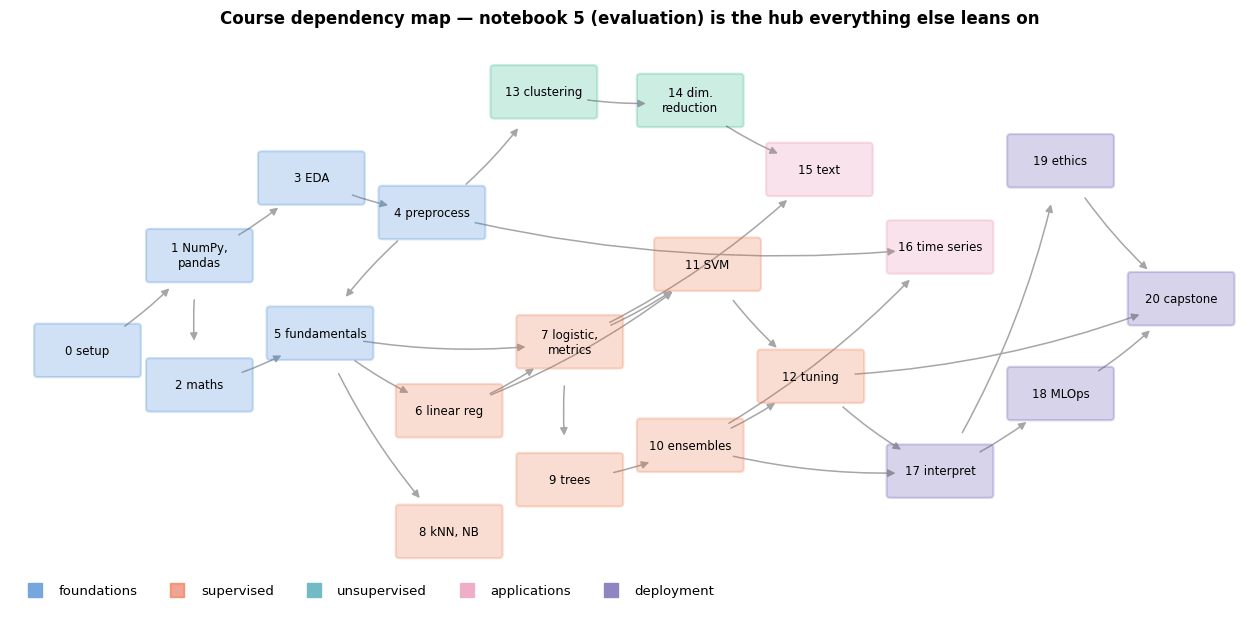

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from course_utils import set_style, PALETTE

set_style()

# (x, y) positions on a hand-laid grid, plus the block each notebook belongs to
BLOCKS = {"foundations": PALETTE[0], "supervised": PALETTE[1], "unsupervised": PALETTE[2],
          "applications": PALETTE[4], "deployment": PALETTE[6]}
NODES = {
    0:  ("0 setup", 0.0, 3.0, "foundations"),
    1:  ("1 NumPy,\npandas", 1.3, 4.1, "foundations"),
    2:  ("2 maths", 1.3, 2.6, "foundations"),
    3:  ("3 EDA", 2.6, 5.0, "foundations"),
    4:  ("4 preprocess", 4.0, 4.6, "foundations"),
    5:  ("5 fundamentals", 2.7, 3.2, "foundations"),
    6:  ("6 linear reg", 4.2, 2.3, "supervised"),
    7:  ("7 logistic,\nmetrics", 5.6, 3.1, "supervised"),
    8:  ("8 kNN, NB", 4.2, 0.9, "supervised"),
    9:  ("9 trees", 5.6, 1.5, "supervised"),
    10: ("10 ensembles", 7.0, 1.9, "supervised"),
    11: ("11 SVM", 7.2, 4.0, "supervised"),
    12: ("12 tuning", 8.4, 2.7, "supervised"),
    13: ("13 clustering", 5.3, 6.0, "unsupervised"),
    14: ("14 dim.\nreduction", 7.0, 5.9, "unsupervised"),
    15: ("15 text", 8.5, 5.1, "applications"),
    16: ("16 time series", 9.9, 4.2, "applications"),
    17: ("17 interpret", 9.9, 1.6, "deployment"),
    18: ("18 MLOps", 11.3, 2.5, "deployment"),
    19: ("19 ethics", 11.3, 5.2, "deployment"),
    20: ("20 capstone", 12.7, 3.6, "deployment"),
}
EDGES = [(0, 1), (1, 2), (1, 3), (2, 5), (3, 4), (4, 5), (5, 6), (5, 8), (5, 7), (6, 7),
         (7, 9), (9, 10), (6, 11), (7, 11), (10, 12), (11, 12), (4, 13), (13, 14),
         (14, 15), (7, 15), (4, 16), (10, 16), (10, 17), (12, 17), (17, 18), (17, 19),
         (18, 20), (19, 20), (12, 20)]

fig, ax = plt.subplots(figsize=(16, 7.5))
for a, b in EDGES:
    x1, y1, x2, y2 = NODES[a][1], NODES[a][2], NODES[b][1], NODES[b][2]
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=11,
                                 color="0.65", lw=1.1, shrinkA=32, shrinkB=32,
                                 connectionstyle="arc3,rad=0.09", zorder=1))
for label, x, y, block in NODES.values():
    ax.add_patch(FancyBboxPatch((x - 0.58, y - 0.27), 1.16, 0.54, boxstyle="round,pad=0.04",
                                facecolor=BLOCKS[block], alpha=0.22, edgecolor=BLOCKS[block],
                                linewidth=1.6, zorder=2))
    ax.text(x, y, label, ha="center", va="center", fontsize=8.5, zorder=3)

handles = [plt.Line2D([], [], marker="s", ls="", markersize=10, color=c, alpha=0.6, label=b)
           for b, c in BLOCKS.items()]
ax.legend(handles=handles, loc="lower left", ncol=5, fontsize=9.5)
ax.set_xlim(-0.9, 13.5)
ax.set_ylim(0.0, 6.7)
ax.axis("off")
ax.set_title("Course dependency map — notebook 5 (evaluation) is the hub everything else leans on")
plt.show()

### 2.1 Three paths through the course

You do not have to walk the whole graph in order.

**The fast path to a working model** (about 15 hours) — 1, 4, 5, 7, 10, 12, 20. Enough to
build, tune and honestly evaluate a gradient-boosted classifier on your own tabular data.
Come back for the rest once you have a problem that demands it.

**The full path** — 0 through 20 in order. This is the intended route and the one the
cross-references assume.

**The theory-first path** — 2, 5, 6, 7, 8, 9, 11, then the rest. If you already know
pandas and want the mathematics before the tooling, start with the maths notebook, go
straight to the learning problem, and take the methods in roughly the order in which the
field discovered them.

If you only ever read one notebook, read number 5.

## 3. Ten minutes, end to end

Before any of the detail, here is the entire supervised-learning workflow in one pass, on
real data: 569 breast tumours described by 30 features computed from digitised images of
cell nuclei, each labelled malignant or benign (Street, Wolberg & Mangasarian, 1993). The
goal is to predict the diagnosis for a tumour the model has never seen.

Every step is labelled with the notebook that explains it properly. Do not worry about
understanding the details yet — the point is to see the shape of the thing.

In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

RANDOM_STATE = 42

# --- step 1: get the data, and look at it  ....................... notebook 3
cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target        # y: 0 = malignant, 1 = benign
print(f"{X.shape[0]} tumours, {X.shape[1]} features, {y.mean():.1%} benign")

# --- step 2: hold out a test set BEFORE anything else  ........... notebook 5
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

# --- step 3: preprocessing lives INSIDE the model  ............... notebook 4
model = Pipeline([("scale", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])

# --- step 4: always compare against a baseline  .................. notebook 5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline = cross_val_score(DummyClassifier(strategy="most_frequent"), X_train, y_train, cv=cv)
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"baseline accuracy (always predict benign): {baseline.mean():.3f}")
print(f"cross-validated ROC-AUC: {scores.mean():.4f} ± {scores.std(ddof=1)/np.sqrt(5):.4f}")

569 tumours, 30 features, 62.7% benign
baseline accuracy (always predict benign): 0.627
cross-validated ROC-AUC: 0.9962 ± 0.0020


The model is fitted on the training data and then — once — applied to the test set we have
not touched.

In [5]:
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
                             classification_report, recall_score)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"test accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"recall on malignant tumours: {recall_score(y_test, y_pred, pos_label=0):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

test accuracy: 0.986
recall on malignant tumours: 0.981

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



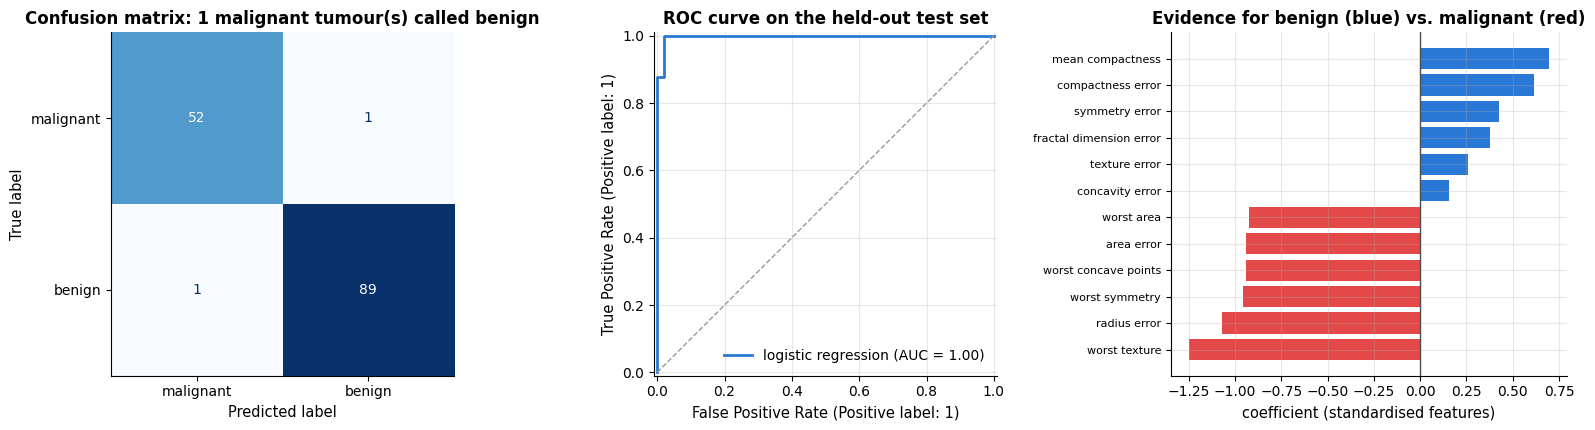

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

# --- step 5: evaluate with the right metrics  .................... notebook 7
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["malignant", "benign"],
                                        cmap="Blues", colorbar=False, ax=axes[0])
missed = int(((y_test == 0) & (y_pred == 1)).sum())
axes[0].set_title(f"Confusion matrix: {missed} malignant tumour(s) called benign")
axes[0].grid(False)

RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name="logistic regression")
axes[1].plot([0, 1], [0, 1], ls="--", color="0.6", lw=1)
axes[1].set_title("ROC curve on the held-out test set")

# --- step 6: ask what the model actually learned  ................ notebook 17
coefs = pd.Series(model.named_steps["clf"].coef_[0], index=X.columns).sort_values()
top = pd.concat([coefs.head(6), coefs.tail(6)])
colors = [PALETTE[7] if c < 0 else PALETTE[0] for c in top]
axes[2].barh(range(len(top)), top.values, color=colors)
axes[2].set_yticks(range(len(top)), [t[:24] for t in top.index], fontsize=8)
axes[2].axvline(0, color="0.3", lw=1)
axes[2].set_xlabel("coefficient (standardised features)")
axes[2].set_title("Evidence for benign (blue) vs. malignant (red)")

plt.tight_layout()
plt.show()

That is the whole loop: **look at the data, hold out a test set, put preprocessing in a
pipeline, beat a baseline, cross-validate, evaluate on data you never touched, and ask what
the model learned.** Everything in the next twenty notebooks is either a deeper look at one
of those steps or a better model to slot into the middle of it.

Notice what the metrics say that accuracy alone would hide: the model misses a few
malignant tumours, and in a screening context those false negatives are far more costly
than false alarms. Choosing the decision threshold to reflect that asymmetry is notebook 7;
deciding whether the model should be deployed at all is notebook 19.

## 4. Conventions used throughout

### 4.1 Notation

| Symbol | Meaning |
|---|---|
| $n$, $d$ | number of samples, number of features |
| $\mathbf{x}_i \in \mathbb{R}^d$, $y_i$ | feature vector and target of sample $i$ |
| $\mathbf{X} \in \mathbb{R}^{n \times d}$, $\mathbf{y} \in \mathbb{R}^n$ | design matrix, target vector |
| $\mathbf{w}$, $b$ (or $\boldsymbol{\theta}$) | weights, bias (all parameters) |
| $\hat{y} = f(\mathbf{x}; \boldsymbol{\theta})$ | prediction |
| $\mathcal{L}(\boldsymbol{\theta})$, $\ell(y, \hat{y})$ | total loss, per-sample loss |
| $\eta$ | learning rate |
| $\lambda$ (scikit-learn: `alpha`, or `C` $= 1/\lambda$) | regularisation strength |
| $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$ | training set |
| $\mathbb{E}[\cdot]$, $\operatorname{Var}[\cdot]$, $P(\cdot)$ | expectation, variance, probability |
| $\sigma(z) = 1/(1+e^{-z})$ | logistic sigmoid |
| $\lVert\cdot\rVert_2$, $\lVert\cdot\rVert_1$ | Euclidean and Manhattan norms |

Vectors are column vectors; $\mathbf{w}^\top \mathbf{x}$ is the dot product. Learned
quantities in scikit-learn end in an underscore (`coef_`, `feature_importances_`);
hyper-parameters are constructor arguments.

### 4.2 The helper module

`notebooks/course_utils.py` is small and worth reading: it sets the plotting style, holds
the colour palette, draws decision boundaries, and loads the datasets. Nothing is hidden in
it — open it whenever you wonder what a helper does.

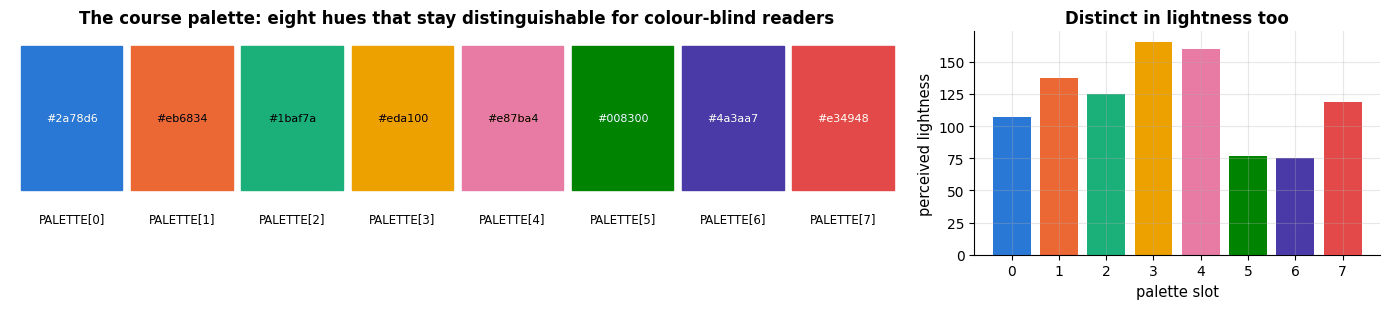

helpers: PALETTE, RANDOM_STATE, set_style, plot_decision_boundary


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.2),
                         gridspec_kw={"width_ratios": [2.2, 1]})

for i, c in enumerate(PALETTE):
    axes[0].add_patch(plt.Rectangle((i, 0), 0.92, 1, color=c))
    axes[0].text(i + 0.46, -0.22, f"PALETTE[{i}]", ha="center", fontsize=8.5)
    axes[0].text(i + 0.46, 0.5, c, ha="center", va="center", fontsize=8,
                 color="white" if i in (0, 5, 6, 7) else "black")
axes[0].set_xlim(-0.1, len(PALETTE))
axes[0].set_ylim(-0.45, 1.1)
axes[0].axis("off")
axes[0].set_title("The course palette: eight hues that stay distinguishable for colour-blind readers")

# the same palette as a colour-blind simulation would compress it: lightness only
lightness = [0.299 * int(c[1:3], 16) + 0.587 * int(c[3:5], 16) + 0.114 * int(c[5:7], 16)
             for c in PALETTE]
axes[1].bar(range(len(PALETTE)), lightness, color=PALETTE)
axes[1].set_xticks(range(len(PALETTE)))
axes[1].set_ylabel("perceived lightness")
axes[1].set_xlabel("palette slot")
axes[1].set_title("Distinct in lightness too")
plt.tight_layout()
plt.show()

print("helpers:", ", ".join(n for n in cu.__all__ if not n.startswith("load_")))

Sequential data uses `viridis`, diverging data (correlations, signed effects) uses `RdBu_r`
centred at zero, and confusion matrices use `Blues`. There are no rainbow colour maps and
no dual-axis charts anywhere in the course; notebook 3 explains why.

### 4.3 Exercises, citations and further reading

Every notebook ends with four to six exercises, ordered from easy to hard, each with a
collapsible solution sketch — the key idea and the core code rather than a full answer.
Citations in the text are author–year ("random forests (Breiman, 2001)"), with full entries
in each notebook's reference list. `REFERENCES.md` in the course folder collects every one
of them in a single bibliography, grouped by topic and marked where the work is legally
free to read. If you want one book alongside this course, make it *An Introduction to
Statistical Learning with Applications in Python* (James et al., 2023), which is free
online and follows a similar arc.

### 4.4 The datasets

The course uses two kinds of data, deliberately, and always says which is which.

**Real datasets** are used for every case study, because real data is messy in ways no
simulation reproduces. Most are bundled with scikit-learn and need no download.

**Simulated datasets** ship with the course in `data/`, generated by `data/make_datasets.py`
with fixed seeds. They exist because when you write the data-generating process yourself
you know the ground truth — you can check whether a model recovers the effect you put in,
demonstrate a bias mechanism exactly, or create a failure mode on demand. That makes them
excellent for teaching and useless as evidence about the world, so the course never draws a
real-world conclusion from them.

In [8]:
from sklearn.datasets import load_wine, load_digits, load_diabetes

datasets = [
    ("breast cancer", "real", load_breast_cancer().data.shape, "binary classification (medical)"),
    ("wine", "real", load_wine().data.shape, "3-class classification (chemistry)"),
    ("digits", "real", load_digits().data.shape, "10-class classification (images)"),
    ("diabetes", "real", load_diabetes().data.shape, "regression (medical)"),
    ("air passengers", "real", (len(cu.load_air_passengers()), 1), "forecasting (Box & Jenkins)"),
    ("customer churn", "simulated", cu.load_churn().shape, "the running tabular example"),
    ("energy demand", "simulated", cu.load_energy_demand().shape, "hourly time series"),
    ("loan applications", "simulated", cu.load_loans().shape, "fairness, with a known bias"),
    ("product reviews", "simulated", cu.load_reviews().shape, "text classification"),
]
overview = pd.DataFrame(datasets, columns=["dataset", "kind", "shape", "used for"])
overview["shape"] = overview["shape"].map(lambda s: f"{s[0]:,} x {s[1]}")
overview

,dataset,kind,shape,used for
0,breast cancer,real,569 x 30,binary classification (medical)
1,wine,real,178 x 13,3-class classification (chemistry)
2,digits,real,"1,797 x 64",10-class classification (images)
3,diabetes,real,442 x 10,regression (medical)
4,air passengers,real,144 x 1,forecasting (Box & Jenkins)
5,customer churn,simulated,"5,000 x 15",the running tabular example
6,energy demand,simulated,"17,520 x 4",hourly time series
7,loan applications,simulated,"6,000 x 13","fairness, with a known bias"
8,product reviews,simulated,"2,400 x 5",text classification


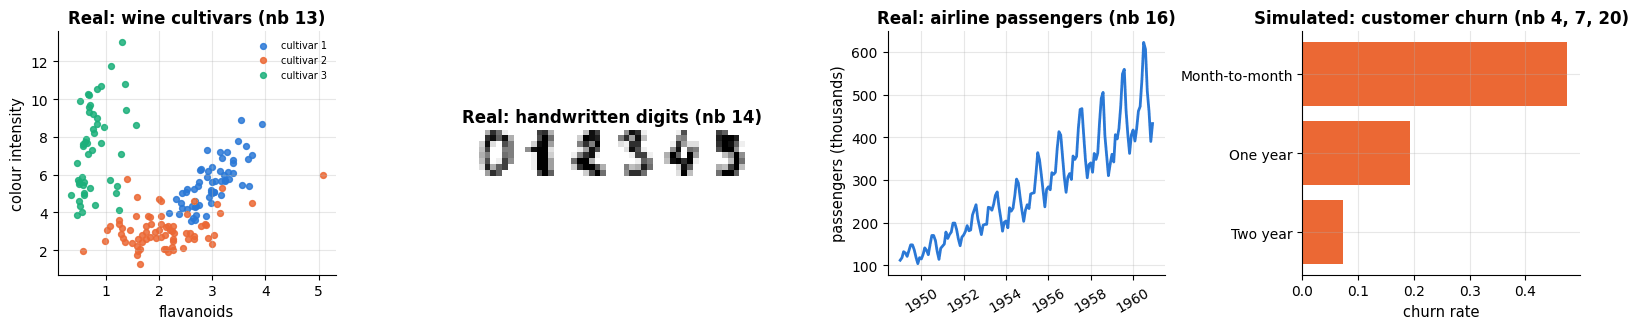

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))

# a real classification dataset: two features of the wine data
wine = load_wine(as_frame=True)
for k in range(3):
    m = wine.target == k
    axes[0].scatter(wine.data.loc[m, "flavanoids"], wine.data.loc[m, "color_intensity"],
                    s=18, color=PALETTE[k], label=f"cultivar {k + 1}", alpha=0.85)
axes[0].set_xlabel("flavanoids")
axes[0].set_ylabel("colour intensity")
axes[0].set_title("Real: wine cultivars (nb 13)")
axes[0].legend(fontsize=7)

# a real image dataset
digits = load_digits()
gallery = np.hstack([digits.images[i] for i in range(6)])
axes[1].imshow(gallery, cmap="gray_r")
axes[1].axis("off")
axes[1].set_title("Real: handwritten digits (nb 14)")

# a real time series
air = cu.load_air_passengers()
axes[2].plot(air.index, air.values, color=PALETTE[0])
axes[2].set_ylabel("passengers (thousands)")
axes[2].set_title("Real: airline passengers (nb 16)")
axes[2].tick_params(axis="x", labelrotation=30)

# a simulated dataset: churn rate by contract type
rates = cu.load_churn().groupby("contract")["churned"].mean().sort_values()
axes[3].barh(rates.index, rates.values, color=PALETTE[1])
axes[3].set_xlabel("churn rate")
axes[3].set_title("Simulated: customer churn (nb 4, 7, 20)")

plt.tight_layout()
plt.show()

Four loaders (`load_california_housing`, `load_penguins`, `load_adult`, `load_newsgroups`)
download real data the first time they are called. If you are offline or the download is
blocked, they print a one-line notice and fall back to a stand-in with the same columns, so
the notebook still runs — the text always tells you which one you are looking at.

## 5. Before you start

A short checklist:

- [ ] The environment is created and `conda activate ml-course` works.
- [ ] The verification cell above printed no missing core packages.
- [ ] `import course_utils` worked, and the bundled data loaded.
- [ ] You know where `REFERENCES.md` is.
- [ ] You have somewhere to keep notes — a scratch notebook next to the course ones is ideal.
- [ ] You have picked a path (section 2.1) and, ideally, a dataset of your own to try things on as you go.

That last one matters more than it sounds. The exercises are good, but the moment the
course becomes *yours* is when you point one of these methods at a question you actually
care about. Keep a dataset from your own work or interests to hand, and after each notebook
spend twenty minutes applying what you just learned to it. By notebook 20 you will have a
project, and the capstone will tell you how to finish it.

Good luck — start with notebook 1.

## Summary

- This is a hands-on course in **classical machine learning with Python**: twenty-one
  notebooks, each with intuition, mathematics, from-scratch implementations, scikit-learn
  equivalents, experiments, exercises and references. Deep learning is deliberately out of
  scope and covered by a separate course.
- Setup is one command: `conda env create -f environment.yml`, then `conda activate
  ml-course` and `jupyter lab`. The core packages are required; the optional ones are used
  only by guarded sections that skip themselves cleanly.
- The dependency map (section 2) shows what depends on what. **Notebook 5 is the hub** — the
  bias–variance trade-off, cross-validation and data leakage underpin everything after it.
- Every method notebook ends with the same three sections: strengths and weaknesses (with a
  failure mode actually demonstrated), a tuning guide with a picture for every
  hyper-parameter, and a case study on real data.
- Real datasets carry the case studies; simulated ones let us check models against a known
  ground truth. The course always says which is which and never draws a worldly conclusion
  from a simulation.

**Next steps:** notebook 1 (Python, NumPy and pandas for machine learning) makes sure the
tooling is fluent; if you are already comfortable there, skim it for the "DataFrame to
`X`/`y`" section and go on to notebook 2 or 5.

## References and further reading

### The books to keep beside you

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free at https://www.statlearning.com) — The best single companion to this course: same arc, same level, more statistical detail.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free at https://hastie.su.domains/ElemStatLearn/) — The graduate-level reference behind most of what follows.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly. — The other great practical book; its second half covers the deep learning this course leaves out.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. (free at https://probml.github.io/pml-book/book1.html) — If you want the probabilistic view developed properly.
- Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*. Cambridge University Press. (free at https://mml-book.github.io) — The mathematics of notebook 2, at book length.
- VanderPlas, J. (2023). *Python Data Science Handbook* (2nd ed.). O'Reilly. (free at https://jakevdp.github.io/PythonDataScienceHandbook/) — The tooling of notebook 1.
- Molnar, C. (2022). *Interpretable Machine Learning* (2nd ed.). (free at https://christophm.github.io/interpretable-ml-book/) — The book behind notebook 17.
- Barocas, S., Hardt, M., & Narayanan, A. (2023). *Fairness and Machine Learning*. MIT Press. (free at https://fairmlbook.org) — The book behind notebook 19.
- Huyen, C. (2022). *Designing Machine Learning Systems*. O'Reilly. — The book behind notebook 18.

### Two short things to read this week

- Domingos, P. (2012). A few useful things to know about machine learning. *Communications of the ACM*, 55(10), 78–87. — Twelve pages that will save you months. Read it now and again when you finish the course.
- Zinkevich, M. *Rules of Machine Learning: Best Practices for ML Engineering*. Google. https://developers.google.com/machine-learning/guides/rules-of-ml — Forty-three rules from people who run ML in production. Rule #1 is "don't be afraid to launch a product without machine learning".

### Tools and data

- Pedregosa, F., et al. (2011). Scikit-learn: machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. — https://scikit-learn.org/stable/user_guide.html
- Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362. — https://numpy.org/doc/stable/
- McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. — https://pandas.pydata.org/docs/
- Hunter, J. D. (2007). Matplotlib: a 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95. — https://matplotlib.org/stable/
- Kluyver, T., et al. (2016). Jupyter Notebooks — a publishing format for reproducible computational workflows. In *Positioning and Power in Academic Publishing*, IOS Press, 87–90.
- Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *Proceedings of SPIE 1905*, 861–870. — The breast cancer data used in section 3.
- Conda documentation — https://docs.conda.io · Miniforge — https://github.com/conda-forge/miniforge